In [17]:
import pandas as pd
import numpy as np
emendas = pd.read_csv('EmendasParlamentares.csv', encoding='latin1', sep=';')

# UFs que mais usaram emendas 
# Media de Valor de uma emenda
# Funçoes que mais usaram emendas
# Emendas por ano
# Medias de emendas por ano
# gap entre valor empenhado e pago

emendas.head(3)

C:\Users\logeg\AppData\Local\Temp\ipykernel_10504\2626748080.py:3: DtypeWarning: Columns (0,3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  emendas = pd.read_csv('EmendasParlamentares.csv', encoding='latin1', sep=';')


,Código da Emenda,Ano da Emenda,Tipo de Emenda,Código do Autor da Emenda,Nome do Autor da Emenda,Número da emenda,Localidade de aplicação do recurso,Código Município IBGE,Município,Código UF IBGE,...,Código Ação,Nome Ação,Código Plano Orçamentário,Nome Plano Orçamentário,Valor Empenhado,Valor Liquidado,Valor Pago,Valor Restos A Pagar Inscritos,Valor Restos A Pagar Cancelados,Valor Restos A Pagar Pagos
0,Sem informação,2014,Emenda Individual - Transferências com Finalid...,S/I,Sem informação,S/I,SARZEDO - MG,3165537,SARZEDO,3100000,...,8581,ESTRUTURACAO DA REDE DE SERVICOS DE ATENCAO PR...,0000,ESTRUTURACAO DA REDE DE SERVICOS DE ATENCAO BA...,"100000,00","0,00","0,00","0,00","0,00","100000,00"
1,Sem informação,2014,Emenda Individual - Transferências com Finalid...,S/I,Sem informação,S/I,RIBEIRÃO CORRENTE - SP,3543105,RIBEIRÃO CORRENTE,3500000,...,1D73,APOIO A POLITICA NACIONAL DE DESENVOLVIMENTO U...,0000,APOIO A POLITICA NACIONAL DE DESENVOLVIMENTO U...,"944995,00","0,00","0,00","0,00","0,00","944995,00"
2,Sem informação,2014,Emenda Individual - Transferências com Finalid...,S/I,Sem informação,S/I,CURRAL DE CIMA - PB,2505279,CURRAL DE CIMA,2500000,...,8581,ESTRUTURACAO DA REDE DE SERVICOS DE ATENCAO PR...,0000,ESTRUTURACAO DA REDE DE SERVICOS DE ATENCAO BA...,"200000,00","0,00","0,00","0,00","0,00","200000,00"


In [18]:
# excluindo colunas que não serão úteis:
emendas = emendas.drop(["Código da Emenda", "Tipo de Emenda", "Código Município IBGE", "Município", "Nome do Autor da Emenda", "Código do Autor da Emenda", "Número da emenda", "Código Ação", "Código Plano Orçamentário", "Valor Liquidado", "Valor Restos A Pagar Inscritos"], axis=1)
# colunas "Código da Emenda", "Código Município IBGE" e "Município" possuiam muitos campos "Sem informação", foram excluídos porque não serão utilizados

In [ ]:
#limpando campos Sem informação
emendas = emendas.replace("Sem informação", np.nan) # substitui os celulas com valor "Sem informação" por vazio
emendas = emendas.dropna() # Exclui toda a linha caso tenha pelo menos um valor vazio
print(emendas.shape)

(83886, 17)


In [61]:
# Substituindo valores "Múltiplos" por "Interestadual" da coluna UF
emendas['UF'] = emendas['UF'].replace("Múltiplo", "Interestadual")

In [ ]:
# transformando colunas de texto em numero:
colunas_a_transformar = ["Valor Empenhado", "Valor Pago", "Valor Restos A Pagar Cancelados", "Valor Restos A Pagar Pagos"]

def tranformar_em_int(colunas):
    for coluna in colunas:
        emendas[coluna] = emendas[coluna].astype(str).str.replace(',', '.', regex=False).astype(float)    

tranformar_em_int(colunas_a_transformar)

float64
float64
float64
float64


Valor Empenhado                     640050.0
Valor Pago                               0.0
Valor Restos A Pagar Cancelados      2328.81
Valor Restos A Pagar Pagos         637721.19
Name: 21, dtype: object

In [110]:
# criando medidas:
def calcular_medidas():
    global media_por_uf, total_por_uf_bi, total_por_funcao_bi, quantidade_por_ano, total_por_ano, media_por_ano, gap_empenhado_e_pago
    media_por_uf = emendas.groupby(emendas["UF"]).mean(numeric_only=True).round(2)

    total_por_uf = emendas.groupby(emendas["UF"]).sum(numeric_only=True).round(2)
    total_por_uf_bi = total_por_uf / 1000000000 # total gasto por bilhao

    total_por_funcao = emendas.groupby(emendas["Nome Função"]).sum(numeric_only=True).round(2)
    total_por_funcao_bi = total_por_funcao / 1000000000 # total gasto por bilhao

    quantidade_por_ano = emendas.groupby(emendas["Ano da Emenda"]).count().round(2)

    total_por_ano = emendas.groupby(emendas["Ano da Emenda"]).sum(numeric_only=True).round(2)

    media_por_ano = emendas.groupby(emendas["Ano da Emenda"]).mean(numeric_only=True).round(2)
    gap_empenhado_e_pago = emendas["Valor Empenhado"].sum(numeric_only=True) - emendas["Valor Pago"].sum(numeric_only=True)
    gap_empenhado_e_pago = gap_empenhado_e_pago.round(2)

calcular_medidas()

display(total_por_ano)


,Código UF IBGE,Valor Empenhado,Valor Pago,Valor Restos A Pagar Cancelados,Valor Restos A Pagar Pagos
Ano da Emenda,,,,,
2014,36607600000,6.027787e+09,1.307475e+08,1.382643e+09,4.455653e+09
2015,11455199930,3.345301e+09,1.976054e+07,5.613464e+08,2.714569e+09
2016,24115199790,1.441512e+10,5.473875e+09,1.537804e+09,6.999404e+09
2017,28711399664,1.399797e+10,3.226283e+09,1.637062e+09,8.623337e+09
2018,21323099370,1.184807e+10,5.400222e+09,1.053289e+09,5.172871e+09
2019,25294599650,1.322116e+10,5.724926e+09,8.615224e+08,6.071346e+09
2020,23960297648,3.194845e+10,1.438131e+10,2.974779e+09,1.328743e+10
2021,19142199174,3.274884e+10,1.550857e+10,1.872867e+09,1.262316e+10
2022,17436499062,2.506502e+10,1.687503e+10,5.313179e+08,6.468486e+09


C:\Users\logeg\AppData\Local\Temp\ipykernel_10504\2652751736.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


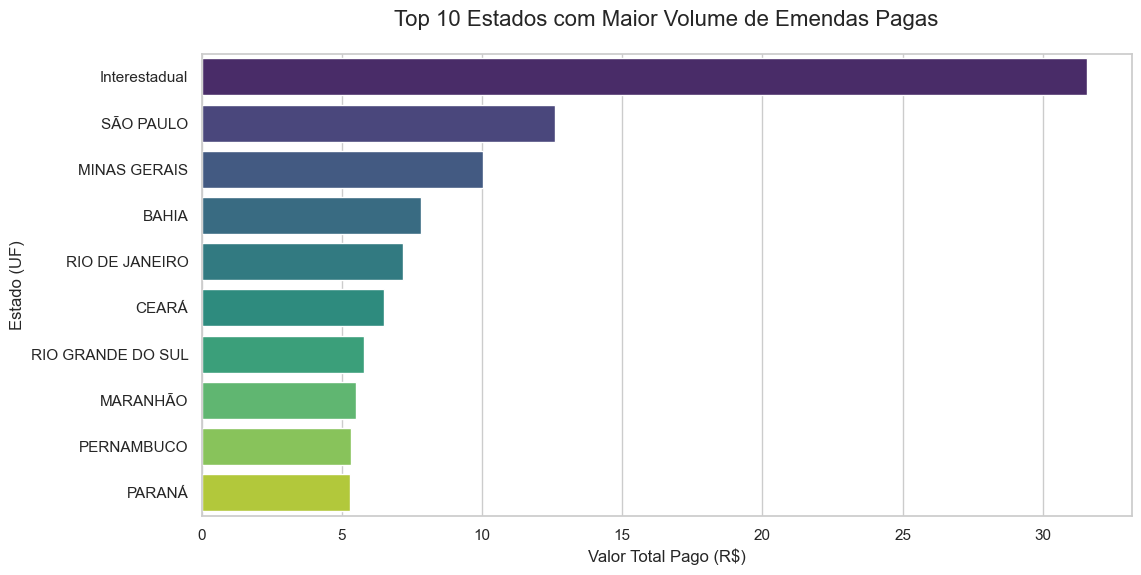

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ordendando e limitando a 10 primeiras linhas
top_10_uf = total_por_uf_bi.sort_values(by='Valor Pago', ascending=False).head(10)

# visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

grafico = sns.barplot(
    data=top_10_uf, 
    x='Valor Pago', 
    y='UF', 
    palette='viridis'
)

plt.title('Top 10 Estados com Maior Volume de Emendas Pagas', fontsize=16, pad=20) #titulo
plt.xlabel('Valor Total Pago (BI)', fontsize=12) 
plt.ylabel('Estado (UF)', fontsize=12)

# salvando
# # plt.savefig('grafico_emendas_uf.png', bbox_inches='tight', dpi=300)

plt.show()
plt.close()

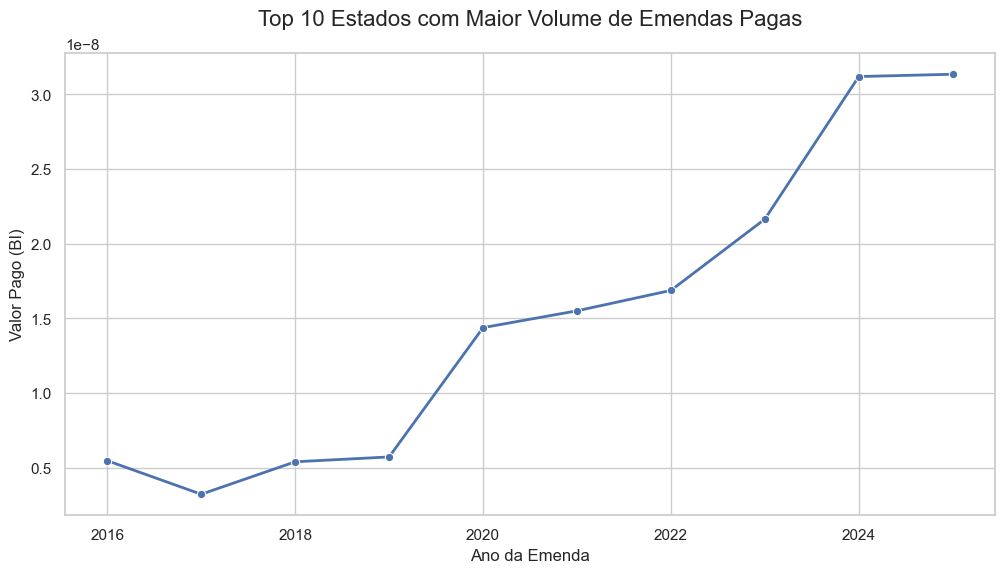

In [ ]:
# transformando em bilhao
total_por_ano["Valor Pago"] = total_por_ano["Valor Pago"] / 1000000000

# definindo visual
sns.set_theme(style="whitegrid") 
plt.figure(figsize=(12, 6))


grafico = sns.lineplot(
    data=total_por_ano, 
    x='Ano da Emenda', 
    y='Valor Pago', 
    marker='o', 
    linewidth=2
)

plt.title('Emendas ao longo dos anos', fontsize=16, pad=20)
plt.xlabel('Ano da Emenda', fontsize=12)
plt.ylabel('Valor Pago (BI)', fontsize=12)

#salvando
# plt.savefig('grafico_emendas_uf.png', bbox_inches='tight', dpi=300)

plt.show()
plt.close()